London Carpool Connect - API-Based Matching

In this notebook I improve the baseline model by using OpenRouteService to calculate road-based distance and journey time.

This version is more realistic because it estimates the driver's detour when picking up and dropping off a passenger. I only use a smaller sample because API calls are slower and may have usage limits.


In [32]:
!pip install openrouteservice

In [33]:
import pandas as pd
import numpy as np
import openrouteservice
import time
from datetime import datetime
from math import radians, sin, cos, sqrt, atan2

In [34]:
passengers = pd.read_csv("/content/passengers.csv")
drivers = pd.read_csv("/content/drivers.csv")
locations = pd.read_csv("/content/LondonLocationsDataset.csv")

print("Passengers:", passengers.shape)
print("Drivers:", drivers.shape)
print("Locations:", locations.shape)

Passengers: (50, 16)
Drivers: (20, 17)
Locations: (30, 5)


In [35]:
ORS_API_KEY = "eyJvcmciOiI1YjNjZTM1OTc4NTExMTAwMDFjZjYyNDgiLCJpZCI6IjQ2YTc2YWJkMzVkZjQ3NjA5YTU4ZGE2ZDk5MWY0YzRmIiwiaCI6Im11cm11cjY0In0="
client = openrouteservice.Client(key=ORS_API_KEY)

In [36]:
coords = (
    (-0.1426, 51.5390),  # Camden: longitude, latitude
    (-0.0235, 51.5054)   # Canary Wharf: longitude, latitude
)

route = client.directions(
    coordinates=coords,
    profile="driving-car",
    format="geojson"
)

summary = route["features"][0]["properties"]["summary"]

distance_km = summary["distance"] / 1000
duration_mins = summary["duration"] / 60

print("Driving distance:", round(distance_km, 2), "km")
print("Driving duration:", round(duration_mins, 2), "minutes")

Driving distance: 11.89 km
Driving duration: 34.65 minutes


In [37]:
def get_driving_route(origin_lat, origin_lon, destination_lat, destination_lon):
    # Gets real driving distance and duration from OpenRouteService. Returns: distance_km, duration_mins

    coords = (
        (origin_lon, origin_lat),
        (destination_lon, destination_lat)
    )

    try:
        route = client.directions(
            coordinates=coords,
            profile="driving-car",
            format="geojson"
        )

        summary = route["features"][0]["properties"]["summary"]

        distance_km = summary["distance"] / 1000
        duration_mins = summary["duration"] / 60

        return round(distance_km, 2), round(duration_mins, 2)

    except Exception as e:
        print("API error:", e)
        return None, None

In [38]:
distance_km, duration_mins = get_driving_route(
    51.5390, -0.1426,   # Camden lat/lon
    51.5054, -0.0235    # Canary Wharf lat/lon
)

print(distance_km, "km")
print(duration_mins, "minutes")

11.89 km
34.65 minutes


In [39]:
route_cache = {}

In [40]:
def get_cached_driving_route(origin_name, origin_lat, origin_lon,
                             destination_name, destination_lat, destination_lon):
    # Gets driving route from cache if available. Otherwise calls OpenRouteService and saves result.

    route_key = f"{origin_name}__to__{destination_name}"

    if route_key in route_cache:
        return route_cache[route_key]["distance_km"], route_cache[route_key]["duration_mins"]

    distance_km, duration_mins = get_driving_route(
        origin_lat,
        origin_lon,
        destination_lat,
        destination_lon
    )

    route_cache[route_key] = {
        "origin": origin_name,
        "destination": destination_name,
        "distance_km": distance_km,
        "duration_mins": duration_mins
    }

    time.sleep(1)

    return distance_km, duration_mins

In [41]:
camden = locations[locations["location"] == "Camden"].iloc[0]
canary_wharf = locations[locations["location"] == "Canary Wharf"].iloc[0]

distance_km, duration_mins = get_cached_driving_route(
    "Camden",
    camden["latitude"],
    camden["longitude"],
    "Canary Wharf",
    canary_wharf["latitude"],
    canary_wharf["longitude"]
)

print(distance_km, "km")
print(duration_mins, "minutes")

11.89 km
34.65 minutes


In [42]:
route_cache

{'Camden__to__Canary Wharf': {'origin': 'Camden',
  'destination': 'Canary Wharf',
  'distance_km': 11.89,
  'duration_mins': 34.65}}

In [43]:
def time_difference_minutes(time1, time2):
    # Calculates the difference between two HH:MM times in minutes.

    t1 = datetime.strptime(time1, "%H:%M")
    t2 = datetime.strptime(time2, "%H:%M")
    difference = abs((t1 - t2).total_seconds() / 60)
    return difference


def classify_match(score):
    # Converts numerical match score into a category.

    if score >= 80:
        return "Excellent match"
    elif score >= 60:
        return "Good match"
    elif score >= 40:
        return "Weak match"
    else:
        return "Not recommended"

In [44]:
print(time_difference_minutes("08:00", "08:15"))
print(classify_match(75))

15.0
Good match


In [45]:
def calculate_api_match_score(passenger, driver):
    # Calculates a passenger-driver match score using API-based driving route data. Returns: score, detour_mins, detour_km, carpool_duration_mins

    # Seat availability check
    if driver["seats_available"] <= 0:
        return 0, None, None, None

    # Accessibility check
    if passenger["requires_accessibility"] == True and driver["accepts_accessibility"] == False:
        return 0, None, None, None

    # Time compatibility
    time_diff = time_difference_minutes(
        passenger["preferred_time"],
        driver["departure_time"]
    )

    allowed_time_diff = passenger["time_flexibility_mins"] + driver["time_flexibility_mins"]

    if time_diff > allowed_time_diff:
        time_score = 0
    else:
        time_score = 100 - ((time_diff / allowed_time_diff) * 100)

    # Driver normal route
    normal_distance, normal_duration = get_cached_driving_route(
        driver["origin"],
        driver["origin_lat"],
        driver["origin_lon"],
        driver["destination"],
        driver["destination_lat"],
        driver["destination_lon"]
    )

    # Carpool route leg 1:
    # driver origin to passenger origin
    leg1_distance, leg1_duration = get_cached_driving_route(
        driver["origin"],
        driver["origin_lat"],
        driver["origin_lon"],
        passenger["origin"],
        passenger["origin_lat"],
        passenger["origin_lon"]
    )

    # Carpool route leg 2:
    # passenger origin to passenger destination
    leg2_distance, leg2_duration = get_cached_driving_route(
        passenger["origin"],
        passenger["origin_lat"],
        passenger["origin_lon"],
        passenger["destination"],
        passenger["destination_lat"],
        passenger["destination_lon"]
    )

    # Carpool route leg 3:
    # passenger destination to driver destination
    leg3_distance, leg3_duration = get_cached_driving_route(
        passenger["destination"],
        passenger["destination_lat"],
        passenger["destination_lon"],
        driver["destination"],
        driver["destination_lat"],
        driver["destination_lon"]
    )

    # If any API call failed, return 0
    if None in [normal_distance, normal_duration, leg1_distance, leg1_duration,
                leg2_distance, leg2_duration, leg3_distance, leg3_duration]:
        return 0, None, None, None

    # Calculate carpool route
    carpool_distance = leg1_distance + leg2_distance + leg3_distance
    carpool_duration = leg1_duration + leg2_duration + leg3_duration

    # Calculate detour
    detour_km = carpool_distance - normal_distance
    detour_mins = carpool_duration - normal_duration

    # Sometimes route logic may produce tiny negative detours, so I set them to 0
    if detour_mins < 0:
        detour_mins = 0

    if detour_km < 0:
        detour_km = 0

    # Detour score
    if detour_mins > driver["max_detour_mins"]:
        detour_score = 0
    else:
        detour_score = 100 - ((detour_mins / driver["max_detour_mins"]) * 100)

    # Passenger journey score
    passenger_direct_duration = leg2_duration

    if passenger_direct_duration <= 30:
        passenger_journey_score = 100
    elif passenger_direct_duration <= 60:
        passenger_journey_score = 80
    elif passenger_direct_duration <= 90:
        passenger_journey_score = 60
    else:
        passenger_journey_score = 40

    # Zone similarity score
    zone_score = 0

    if passenger["origin_zone"] == driver["origin_zone"]:
        zone_score += 50

    if passenger["destination_zone"] == driver["destination_zone"]:
        zone_score += 50

    # Sustainability score
    if driver["vehicle_type"] == "Electric":
        sustainability_score = 100
    elif driver["vehicle_type"] == "Hybrid":
        sustainability_score = 80
    elif driver["vehicle_type"] == "Petrol":
        sustainability_score = 50
    else:
        sustainability_score = 40

    # Final weighted score
    final_score = (
        0.35 * detour_score +
        0.25 * time_score +
        0.15 * passenger_journey_score +
        0.15 * zone_score +
        0.10 * sustainability_score
    )

    return round(final_score, 2), round(detour_mins, 2), round(detour_km, 2), round(carpool_duration, 2)

In [46]:
test_passenger = passengers.iloc[0]
test_driver = drivers.iloc[0]

score, detour_mins, detour_km, carpool_duration = calculate_api_match_score(
    test_passenger,
    test_driver
)

print("Passenger:", test_passenger["passenger_id"], test_passenger["origin"], "to", test_passenger["destination"])
print("Driver:", test_driver["driver_id"], test_driver["origin"], "to", test_driver["destination"])
print("API match score:", score)
print("Detour minutes:", detour_mins)
print("Detour km:", detour_km)
print("Carpool duration:", carpool_duration)

Passenger: P001 Wimbledon to Camden
Driver: D001 Peckham to Wembley
API match score: 22.0
Detour minutes: 55.46
Detour km: 21.63
Carpool duration: 114.32


In [47]:
sample_passengers = passengers.head(10)
sample_drivers = drivers.head(10)

print("Sample passengers:", sample_passengers.shape)
print("Sample drivers:", sample_drivers.shape)

Sample passengers: (10, 16)
Sample drivers: (10, 17)


In [48]:
def find_api_matches_for_passenger(passenger, drivers_df, top_n=5):
    # Finds top API-based driver matches for one passenger.

    api_matches = []

    for _, driver in drivers_df.iterrows():
        score, detour_mins, detour_km, carpool_duration = calculate_api_match_score(
            passenger,
            driver
        )

        result = {
            "passenger_id": passenger["passenger_id"],
            "passenger_name": passenger["passenger_name"],
            "passenger_origin": passenger["origin"],
            "passenger_destination": passenger["destination"],
            "passenger_time": passenger["preferred_time"],
            "driver_id": driver["driver_id"],
            "driver_name": driver["driver_name"],
            "driver_origin": driver["origin"],
            "driver_destination": driver["destination"],
            "driver_time": driver["departure_time"],
            "driver_vehicle_type": driver["vehicle_type"],
            "driver_seats_available": driver["seats_available"],
            "api_match_score": score,
            "detour_mins": detour_mins,
            "detour_km": detour_km,
            "carpool_duration_mins": carpool_duration,
            "match_category": classify_match(score)
        }

        api_matches.append(result)

    api_matches_df = pd.DataFrame(api_matches)

    api_matches_df = api_matches_df.sort_values(
        by="api_match_score",
        ascending=False
    )

    return api_matches_df.head(top_n)

In [49]:
passenger_1 = sample_passengers.iloc[0]

api_top_matches = find_api_matches_for_passenger(
    passenger_1,
    sample_drivers,
    top_n=5
)

api_top_matches

,passenger_id,passenger_name,passenger_origin,passenger_destination,passenger_time,driver_id,driver_name,driver_origin,driver_destination,driver_time,driver_vehicle_type,driver_seats_available,api_match_score,detour_mins,detour_km,carpool_duration_mins,match_category
8,P001,William Jennings,Wimbledon,Camden,09:30,D009,Charlotte Haynes,Shoreditch,Chelsea,09:30,Hybrid,4,45.00,89.86,33.66,120.76,Weak match
4,P001,William Jennings,Wimbledon,Camden,09:30,D005,Kayleigh Mitchell,Wimbledon,London Bridge,07:30,Diesel,1,26.83,22.62,7.72,67.13,Not recommended
6,P001,William Jennings,Wimbledon,Camden,09:30,D007,Victor Patel,Chelsea,Wembley,09:15,Hybrid,3,26.25,66.92,25.74,100.48,Not recommended
2,P001,William Jennings,Wimbledon,Camden,09:30,D003,Henry O'Brien,Croydon,Peckham,09:15,Hybrid,1,26.25,70.96,25.72,106.50,Not recommended
7,P001,William Jennings,Wimbledon,Camden,09:30,D008,Eric O'Neill,Tottenham,Ealing,08:15,Electric,3,22.00,105.24,33.37,152.36,Not recommended


In [50]:
def find_api_matches_for_all_passengers(passengers_df, drivers_df, top_n=3):
    # Finds top API-based matches for every passenger in the sample.

    all_api_matches = []

    for _, passenger in passengers_df.iterrows():
        print("Matching passenger:", passenger["passenger_id"])

        passenger_matches = find_api_matches_for_passenger(
            passenger,
            drivers_df,
            top_n=top_n
        )

        all_api_matches.append(passenger_matches)

    all_api_matches_df = pd.concat(all_api_matches, ignore_index=True)

    return all_api_matches_df

In [51]:
api_all_matches = find_api_matches_for_all_passengers(
    sample_passengers,
    sample_drivers,
    top_n=3
)

api_all_matches.head(10)

Matching passenger: P001
Matching passenger: P002


/usr/local/lib/python3.12/dist-packages/openrouteservice/client.py:211: UserWarning: Rate limit exceeded. Retrying for the 1st time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
/usr/local/lib/python3.12/dist-packages/openrouteservice/client.py:211: UserWarning: Rate limit exceeded. Retrying for the 2nd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
/usr/local/lib/python3.12/dist-packages/openrouteservice/client.py:211: UserWarning: Rate limit exceeded. Retrying for the 3rd time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
/usr/local/lib/python3.12/dist-packages/openrouteservice/client.py:211: UserWarning: Rate limit exceeded. Retrying for the 4th time.
  warnings.warn('Rate limit exceeded. Retrying for the {0}{1} time.'.format(retry_counter + 1,
/usr/local/lib/python3.12/dist-packages/openrouteservice/client.py:211: UserWarning: Rat

Matching passenger: P003
Matching passenger: P004
Matching passenger: P005
Matching passenger: P006
Matching passenger: P007
Matching passenger: P008
Matching passenger: P009
Matching passenger: P010


,passenger_id,passenger_name,passenger_origin,passenger_destination,passenger_time,driver_id,driver_name,driver_origin,driver_destination,driver_time,driver_vehicle_type,driver_seats_available,api_match_score,detour_mins,detour_km,carpool_duration_mins,match_category
0,P001,William Jennings,Wimbledon,Camden,09:30,D009,Charlotte Haynes,Shoreditch,Chelsea,09:30,Hybrid,4,45.00,89.86,33.66,120.76,Weak match
1,P001,William Jennings,Wimbledon,Camden,09:30,D005,Kayleigh Mitchell,Wimbledon,London Bridge,07:30,Diesel,1,26.83,22.62,7.72,67.13,Not recommended
2,P001,William Jennings,Wimbledon,Camden,09:30,D007,Victor Patel,Chelsea,Wembley,09:15,Hybrid,3,26.25,66.92,25.74,100.48,Not recommended
3,P002,Lesley Wilson-Newman,Bank,Canary Wharf,07:45,D010,Martyn Wilson,Ealing,Whitechapel,08:45,Petrol,1,38.07,20.94,9.34,73.60,Not recommended
4,P002,Lesley Wilson-Newman,Bank,Canary Wharf,07:45,D002,Philip Clarke,Hackney,Greenwich,08:45,Hybrid,2,23.00,30.04,8.23,52.99,Not recommended
5,P002,Lesley Wilson-Newman,Bank,Canary Wharf,07:45,D009,Charlotte Haynes,Shoreditch,Chelsea,09:30,Hybrid,4,23.00,31.57,12.32,62.47,Not recommended
6,P003,Abdul Hopkins,Richmond,London Bridge,09:30,D009,Charlotte Haynes,Shoreditch,Chelsea,09:30,Hybrid,4,45.00,90.55,37.57,121.45,Weak match
7,P003,Abdul Hopkins,Richmond,London Bridge,09:30,D005,Kayleigh Mitchell,Wimbledon,London Bridge,07:30,Diesel,1,31.00,25.40,14.09,69.91,Not recommended
8,P003,Abdul Hopkins,Richmond,London Bridge,09:30,D003,Henry O'Brien,Croydon,Peckham,09:15,Hybrid,1,26.25,75.06,32.52,110.60,Not recommended
9,P004,Mrs Lauren Green,Paddington,Ealing,07:15,D009,Charlotte Haynes,Shoreditch,Chelsea,09:30,Hybrid,4,30.50,45.65,23.42,76.55,Not recommended


In [52]:
api_all_matches.shape

(30, 17)

In [53]:
api_best_matches = (
    api_all_matches
    .sort_values(by=["passenger_id", "api_match_score"], ascending=[True, False])
    .groupby("passenger_id")
    .head(1)
    .reset_index(drop=True)
)

api_best_matches["final_status"] = np.where(
    api_best_matches["api_match_score"] >= 40,
    "matched",
    "unmatched"
)

api_best_matches

,passenger_id,passenger_name,passenger_origin,passenger_destination,passenger_time,driver_id,driver_name,driver_origin,driver_destination,driver_time,driver_vehicle_type,driver_seats_available,api_match_score,detour_mins,detour_km,carpool_duration_mins,match_category,final_status
0,P001,William Jennings,Wimbledon,Camden,09:30,D009,Charlotte Haynes,Shoreditch,Chelsea,09:30,Hybrid,4,45.00,89.86,33.66,120.76,Weak match,matched
1,P002,Lesley Wilson-Newman,Bank,Canary Wharf,07:45,D010,Martyn Wilson,Ealing,Whitechapel,08:45,Petrol,1,38.07,20.94,9.34,73.60,Not recommended,unmatched
2,P003,Abdul Hopkins,Richmond,London Bridge,09:30,D009,Charlotte Haynes,Shoreditch,Chelsea,09:30,Hybrid,4,45.00,90.55,37.57,121.45,Weak match,matched
3,P004,Mrs Lauren Green,Paddington,Ealing,07:15,D009,Charlotte Haynes,Shoreditch,Chelsea,09:30,Hybrid,4,30.50,45.65,23.42,76.55,Not recommended,unmatched
4,P005,Tina Foster,London Bridge,Waterloo,09:00,D001,Joshua Stewart,Peckham,Wembley,08:00,Electric,3,46.40,11.66,2.92,70.52,Weak match,matched
5,P006,Nigel Edwards,Brixton,Hackney,09:15,D003,Henry O'Brien,Croydon,Peckham,09:15,Hybrid,1,52.50,66.43,20.65,101.97,Weak match,matched
6,P007,Abdul Burton-Patterson,London Bridge,Southwark,08:15,D001,Joshua Stewart,Peckham,Wembley,08:00,Electric,3,53.68,13.99,3.01,72.85,Weak match,matched
7,P008,Sarah Reed-Walsh,Hackney,Lewisham,07:15,D002,Philip Clarke,Hackney,Greenwich,08:45,Hybrid,2,35.00,18.19,7.69,41.14,Not recommended,unmatched
8,P009,Miss Olivia Bryan,Westminster,Croydon,08:15,D008,Eric O'Neill,Tottenham,Ealing,08:15,Electric,3,47.00,101.08,33.23,148.20,Weak match,matched
9,P010,Dr Lee Green,Westminster,Southwark,09:00,D010,Martyn Wilson,Ealing,Whitechapel,08:45,Petrol,1,48.10,11.27,3.76,63.93,Weak match,matched


In [54]:
total_sample_passengers = len(sample_passengers)
matched_sample_passengers = len(api_best_matches[api_best_matches["final_status"] == "matched"])
unmatched_sample_passengers = total_sample_passengers - matched_sample_passengers

api_match_rate = (matched_sample_passengers / total_sample_passengers) * 100
api_average_score = api_best_matches["api_match_score"].mean()
api_average_detour = api_best_matches["detour_mins"].mean()

print("Total sample passengers:", total_sample_passengers)
print("Matched passengers:", matched_sample_passengers)
print("Unmatched passengers:", unmatched_sample_passengers)
print("API match rate:", round(api_match_rate, 2), "%")
print("Average API match score:", round(api_average_score, 2))
print("Average detour minutes:", round(api_average_detour, 2))

Total sample passengers: 10
Matched passengers: 7
Unmatched passengers: 3
API match rate: 70.0 %
Average API match score: 44.12
Average detour minutes: 46.96


In [55]:
api_all_matches.to_csv("api_all_matches.csv", index=False)
api_best_matches.to_csv("api_best_matches.csv", index=False)

In [56]:
route_cache_df = pd.DataFrame(route_cache).T.reset_index(drop=True)

route_cache_df.to_csv("route_cache.csv", index=False)

route_cache_df.head()

,origin,destination,distance_km,duration_mins
0,Camden,Canary Wharf,11.89,34.65
1,Peckham,Wembley,24.98,58.86
2,Peckham,Wimbledon,14.79,36.62
3,Wimbledon,Camden,17.36,46.32
4,Camden,Wembley,14.46,31.38


<Axes: title={'center': 'API-Based Matched vs Unmatched Passengers'}, xlabel='final_status'>

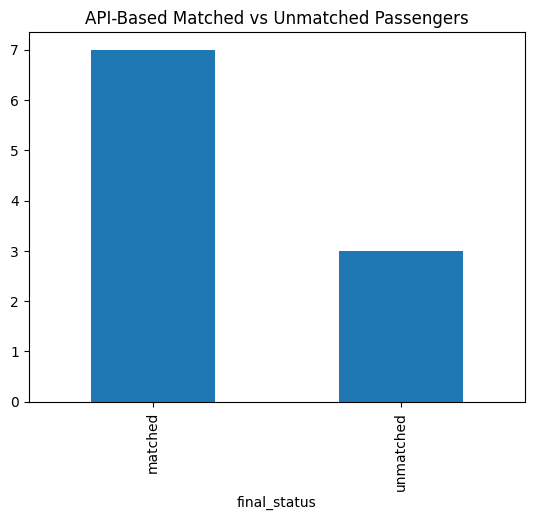

In [57]:
api_best_matches["final_status"].value_counts().plot(
    kind="bar",
    title="API-Based Matched vs Unmatched Passengers"
)

<Axes: title={'center': 'Distribution of API-Based Match Scores'}, ylabel='Frequency'>

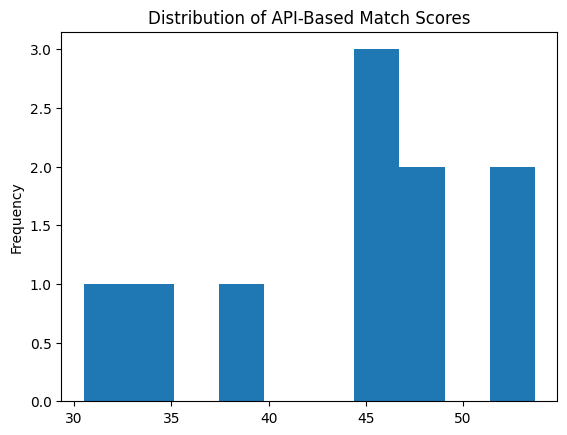

In [58]:
api_best_matches["api_match_score"].plot(
    kind="hist",
    bins=10,
    title="Distribution of API-Based Match Scores"
)

<Axes: title={'center': 'Detour Time for Best API Matches'}>

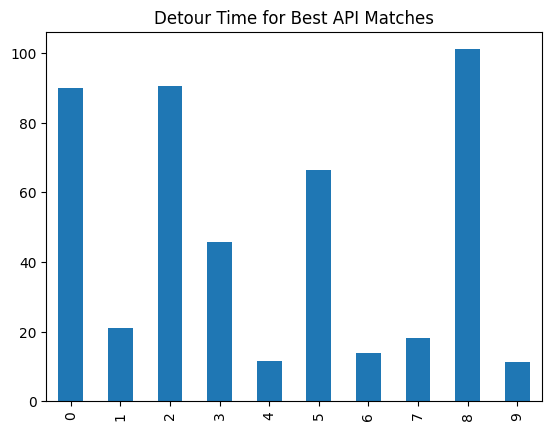

In [59]:
api_best_matches["detour_mins"].plot(
    kind="bar",
    title="Detour Time for Best API Matches"
)